### Uranium Release and Capture by Reduction
Example from Appelo and Rolle, 2010, Groundwater. Uranium containing acid leachate from a mine migrates in to an aquifer exhibiting oxic and anoxic (pyritic) conditions in the upper and lower part of the aquifer, respectively. In the upper (oxic) part, U(6) is retarded by surface complexation reactions with iron oxides. In the lower anoxic and pyrite-bearing part, U(6) becomes reduced to U(4) and readily precipitates as coffinite (USiO4). Also cation exchange processes are considered. 

In [65]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

In [41]:
length_units = 'meters'
time_units = 'days'
sim_name = 'appelo_uran' # Note that the name should only contain small letters
gwf_name = f'gwf_{sim_name}'
gwt_name = f'gwt_{sim_name}'
sim_ws = './mf6'
concentration_name = 'concentration' # name for concentration
rtmf6_sol_number_name = 'rtmf6_sol_number' # solution number of PHREEQC solution

In [42]:
sim = flopy.mf6.MFSimulation(sim_name=sim_name, sim_ws=sim_ws)

nper = 1  
perlen = 7300 
nstp = 730

In [43]:
tdis = flopy.mf6.ModflowTdis(
    sim, 
    nper=nper, 
    perioddata=[(perlen, nstp, 1.0)], 
    time_units=time_units)

#### Groundwater flow (GWF)

In [44]:
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=gwf_name,
    save_flows=True,
    model_nam_file=f"{gwf_name}.nam",
)

In [45]:
#%% Flow solver parameters
nouter, ninner = 300, 600
hclose, rclose, relax = 1e-6, 1e-6, 1.0


imsgwf = flopy.mf6.ModflowIms(
    sim,
    complexity="complex",
    print_option="SUMMARY",
    outer_dvclose=hclose,
    outer_maximum=nouter,
    under_relaxation="NONE",
    inner_maximum=ninner,
    inner_dvclose=hclose,
    rcloserecord=rclose,
    linear_acceleration="CG",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=relax,
    filename=f"{gwf_name}.ims",
)
sim.register_ims_package(imsgwf, [gwf.name])

In [46]:
nlay = 1  # Number of layers
ncol = 100 # Number of columns
nrow = 40  # Number of rows
delr = 20 # 
delc = 1.25
top = 1
botm = np.array([0])
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units=length_units,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top = top,
    botm = botm,
    filename=f"{gwf_name}.dis",
    nogrb=True,
)

In [47]:
k11 = 100.0  # Horizontal hydraulic conductivity ($m/d$)
k33 = k11  # Vertical hydraulic conductivity ($m/d$)
icelltype = 0 # saturated thickness is constant --> confined case


npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_flows=True,
    save_saturation=True,
    icelltype=icelltype,
    k=k11,
    k33=k33,
    save_specific_discharge=True,
    filename=f"{gwf_name}.npf",
)

In [48]:
flopy.mf6.ModflowGwfic(gwf, strt=1, filename=f"{gwf_name}.ic")

package_name = ic
filename = gwf_appelo_uran.ic
package_type = ic
model_or_simulation_package = model
model_name = gwf_appelo_uran

Block griddata
--------------------
strt
{constant 1}



In [49]:
#%% WEL
## The oxic water (solution 1 in rtmf6/advect.pqi) and the acid mine water (solution 3 in rtmf6/advect.pqi) 
## enter from upper and lower left corners via WEL boundaries

q = 1.5 #injection rate m3/d
concentration = 0  # will be replaced


wel_spd = [[(0, 0, 0), q, concentration, 1],[(0, 39, 0), q, concentration, 3]] # well stress period data

auxiliary = [
    concentration_name, # name for concentration
    rtmf6_sol_number_name # solution number of PHREEQC solution
] 
wel = flopy.mf6.ModflowGwfwel(
        gwf,
        stress_period_data=wel_spd,
        save_flows=True,
        auxiliary=auxiliary,
        pname='wel',
        filename=f"{gwf_name}.wel"
    )

In [50]:
#%% CHD, water leaves the aquifer in middle of the right boundary
chd_spd = []
auxiliary = [
    concentration_name, # name for concentration
    rtmf6_sol_number_name # solution number of PHREEQC solution
]


chd_spd.append([(0, 19, 99), 10,0,0])


chd = flopy.mf6.ModflowGwfchd(
    gwf,
    maxbound=len(chd_spd),
    stress_period_data=chd_spd,
    save_flows=False,
    auxiliary=auxiliary,
    pname="CHD",
    filename=f"{gwf_name}.chd",
)

In [51]:
oc_gwf = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{gwf_name}.hds",
    budget_filerecord=f"{gwf_name}.cbb",
    headprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

#### Transport (GWT)

In [52]:
gwt = flopy.mf6.MFModel(
    sim,
    model_type="gwt6",
    modelname=gwt_name,
    model_nam_file=f"{gwt_name}.nam"
)

In [53]:
#%% Transport solver parameters
imsgwt = flopy.mf6.ModflowIms(
    sim,
    print_option="SUMMARY",
    outer_dvclose=hclose,
    outer_maximum=nouter,
    under_relaxation="NONE",
    inner_maximum=ninner,
    inner_dvclose=hclose,
    rcloserecord=rclose,
    linear_acceleration="BICGSTAB",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=relax,
    filename=f"{gwt_name}.ims",
)
sim.register_ims_package(imsgwt, [gwt.name])

In [54]:
gwt_dis = flopy.mf6.ModflowGwtdis(
    gwt,
    length_units=length_units,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top = top,
    botm = botm,
    filename=f"{gwt_name}.dis",
    nogrb=True,
)

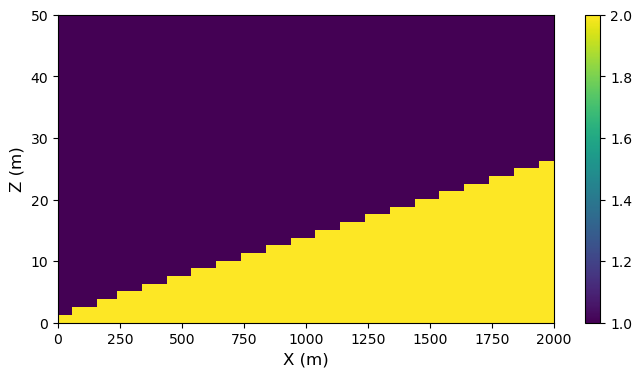

In [72]:
#%% Transport IC
## The initial conditions with respect to solutions, mineral composition, surfaces and exchange are stored in zones.txt
## The upper part has the solution/equilibrium_phases/surface/exchange number 1, the lower part has the number 2 in rtmf6/advect.pqi
zones = np.flipud(np.loadtxt('./zones.txt'))  

gwt_ic = flopy.mf6.ModflowGwtic(
    gwt, 
    strt=zones,  # rtmf6 solution number
    filename=f"{gwt_name}.ic")

# Access model grid
mg = gwf.modelgrid

# Get cell center coordinates
x = mg.xcellcenters
y = mg.ycellcenters

plt.figure(figsize=(8,4))
plt.pcolor(x,y,zones)
ax=plt.gca()
ax.ticklabel_format(style='plain')
plt.xlabel('X (m)',fontsize=12)
plt.ylabel('Z (m)',fontsize=12)
plt.colorbar()
plt.show()

In [56]:
#%% Transport SSM
sourcerecarray = ['wel', 'aux', concentration_name]

ssm = flopy.mf6.ModflowGwtssm(
    gwt, 
    sources=sourcerecarray, 
    save_flows=True,
    print_flows=True,
    filename=f"{gwt_name}.ssm"
)

In [57]:
adv = flopy.mf6.ModflowGwtadv(
    gwt,
    scheme="UPSTREAM",
)

In [58]:
dispersivity = 10
transverse_horizontal_dispersivity = dispersivity * 0.01
transverse_vertical_dispersivity = dispersivity * 0.01

dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=dispersivity,
            ath1=transverse_horizontal_dispersivity,
            atv=transverse_vertical_dispersivity, 
            filename=f"{gwt_name}.dsp",
        )

In [59]:
first_order_decay = None
porosity = 0.2

mst = flopy.mf6.ModflowGwtmst(
    gwt,
    porosity=porosity,
    first_order_decay=first_order_decay,
    filename=f"{gwt_name}.mst",
)

In [60]:
oc_gwt = flopy.mf6.ModflowGwtoc(
    gwt,
    budget_filerecord=f"{gwt_name}.cbb",
    concentration_filerecord=f"{gwt_name}.ucn",
    concentrationprintrecord=[
        ("COLUMNS", 10, "WIDTH", 15, "DIGITS", 10, "GENERAL")
    ],
    saverecord=[("CONCENTRATION", "ALL"), 
                ("BUDGET", "ALL")
                ],
    printrecord=[("CONCENTRATION", "ALL"), 
                 ("BUDGET", "ALL")
                    ],
)

In [61]:
#%% GWF-GWT Exchange
flopy.mf6.ModflowGwfgwt(
    sim,
    exgtype="GWF6-GWT6",
    exgmnamea=gwf_name,
    exgmnameb=gwt_name,
    filename=f"{sim_name}.gwfgwt",
)

package_name = appelo_uran.gwfgwt
filename = appelo_uran.gwfgwt
package_type = gwfgwt
model_or_simulation_package = simulation
simulation_name = appelo_uran


In [62]:
# writing the MF6 files to be used as templates for the RTMF6 input, such as initial conditions 
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_0...
  writing package appelo_uran.gwfgwt...
  writing model gwf_appelo_uran...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package wel...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 2 based on size of stress_period_data
    writing package chd...
    writing package oc...
  writing model gwt_appelo_uran...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package ssm...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing package oc...
